In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(123)

df = pd.read_excel('/content/drive/MyDrive/Statistics-2/Extra-Activity/Activity-5.xlsx')
heights = df['Height'].values

Population mean: 66.36756
Population sigma: 3.847336

n=5: mean of sample means = 66.449113, sd = 1.840964, theoretical SE = 1.720581


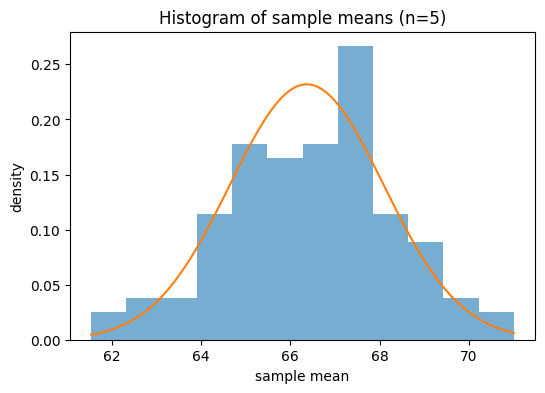

  For sums (standardized): mean(Z)=0.0474, sd(Z)=1.0700


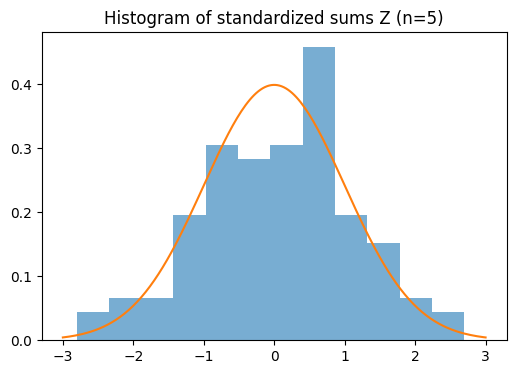


n=10: mean of sample means = 66.604849, sd = 1.210076, theoretical SE = 1.216634


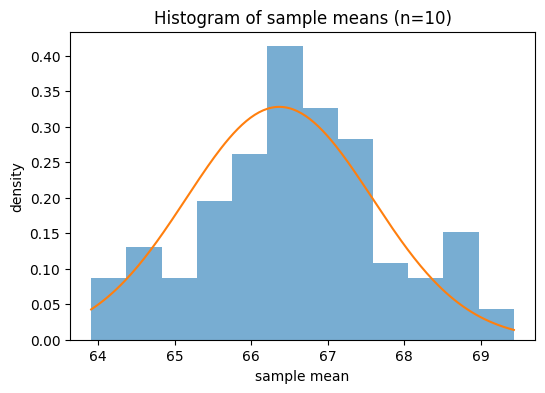

  For sums (standardized): mean(Z)=0.1950, sd(Z)=0.9946


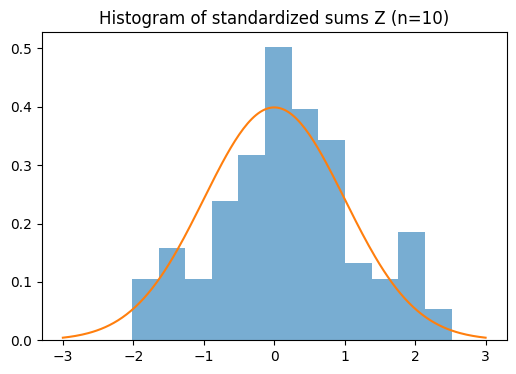


n=30: mean of sample means = 66.264892, sd = 0.654985, theoretical SE = 0.702424


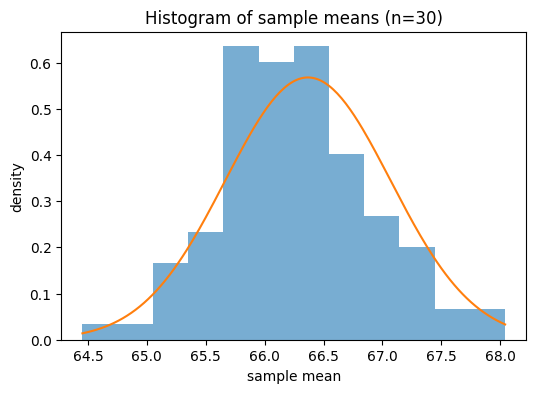

  For sums (standardized): mean(Z)=-0.1462, sd(Z)=0.9325


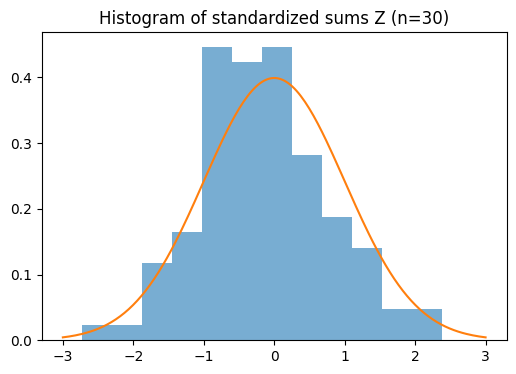


n=50: mean of sample means = 66.402581, sd = 0.563667, theoretical SE = 0.544095


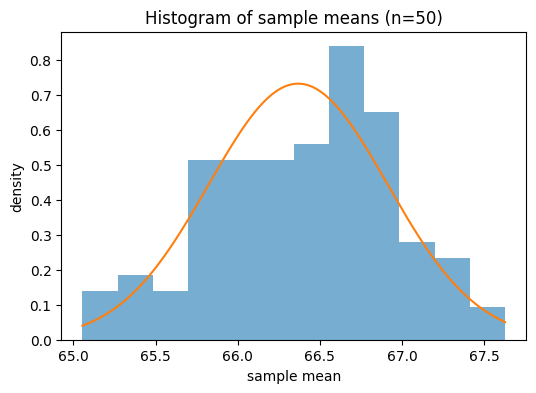

  For sums (standardized): mean(Z)=0.0644, sd(Z)=1.0360


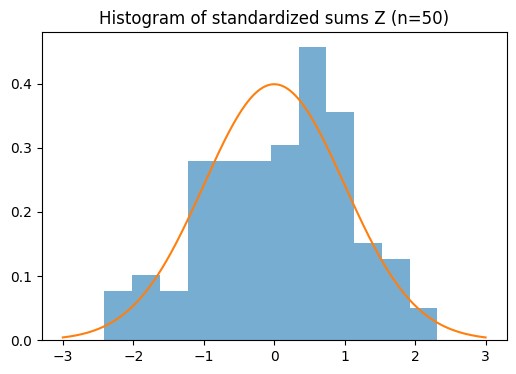


n=100: mean of sample means = 66.380493, sd = 0.403552, theoretical SE = 0.384734


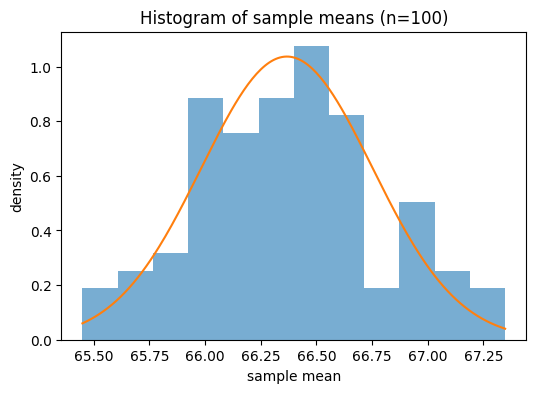

  For sums (standardized): mean(Z)=0.0336, sd(Z)=1.0489


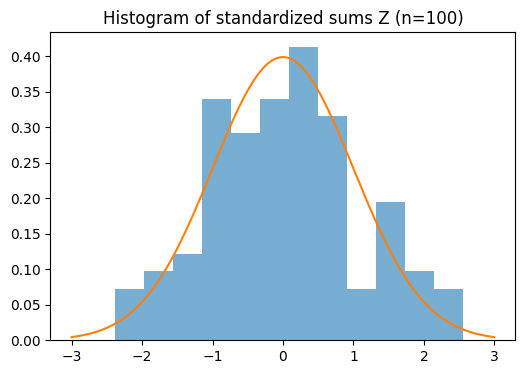

In [ ]:
# Population stats
mu = heights.mean()
sigma = heights.std(ddof=0)   # population std
print("Population mean:", round(mu,6))
print("Population sigma:", round(sigma,6))

# Settings
n_list = [5,10,30,50,100]
R = 100  # number of repeated samples per n

results = []
for n in n_list:
    sample_means = []
    sample_sums = []
    for _ in range(R):
        sample = np.random.choice(heights, size=n, replace=True)
        sample_means.append(sample.mean())
        sample_sums.append(sample.sum())
    sample_means = np.array(sample_means)
    sample_sums = np.array(sample_sums)

    emp_mean_of_means = sample_means.mean()
    emp_sd_of_means = sample_means.std(ddof=0)
    theoretical_se = sigma / np.sqrt(n)

    print(f"\nn={n}: mean of sample means = {emp_mean_of_means:.6f}, sd = {emp_sd_of_means:.6f}, theoretical SE = {theoretical_se:.6f}")
    results.append((n, emp_mean_of_means, emp_sd_of_means, theoretical_se))

    # Plot histogram of sample means and overlay normal curve
    plt.figure(figsize=(6,4))
    plt.hist(sample_means, bins=12, density=True, alpha=0.6)
    x = np.linspace(sample_means.min(), sample_means.max(), 200)
    plt.plot(x, norm.pdf(x, loc=mu, scale=theoretical_se))
    plt.title(f"Histogram of sample means (n={n})")
    plt.xlabel("sample mean")
    plt.ylabel("density")
    plt.show()

    # Case II standardized sums Z
    Z = (sample_sums - n*mu) / (sigma * np.sqrt(n))
    print(f"  For sums (standardized): mean(Z)={Z.mean():.4f}, sd(Z)={Z.std(ddof=0):.4f}")
    plt.figure(figsize=(6,4))
    plt.hist(Z, bins=12, density=True, alpha=0.6)
    x = np.linspace(-3,3,200)
    plt.plot(x, norm.pdf(x, 0, 1))
    plt.title(f"Histogram of standardized sums Z (n={n})")
    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Statistics-2/Extra-Activity/Activity-5.xlsx')
heights = df['Height'].values